In [56]:
# imports
import glob
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from dotenv import load_dotenv
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

# Loading

In [31]:
load_dotenv()
path = kagglehub.dataset_download("chethuhn/network-intrusion-dataset")

# read all CSV files in the dataset directory, create df
csv_files = glob.glob(os.path.join(path, "*.csv"))
df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
df

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,22,166,1,1,0,0,0,0,0.0,0.0,...,32,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
1,60148,83,1,2,0,0,0,0,0.0,0.0,...,32,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
2,123,99947,1,1,48,48,48,48,48.0,0.0,...,40,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
3,123,37017,1,1,48,48,48,48,48.0,0.0,...,32,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
4,0,111161336,147,0,0,0,0,0,0.0,0.0,...,0,1753752.625,2123197.578,4822992,95,9463032.7,2657727.996,13600000,5700287,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2830738,443,18738,1,1,6,6,6,6,6.0,0.0,...,20,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
2830739,53,60797,2,2,80,156,40,40,40.0,0.0,...,32,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
2830740,53,154,2,2,64,96,32,32,32.0,0.0,...,32,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
2830741,53,155,2,2,80,144,40,40,40.0,0.0,...,20,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN


# Cleaning

In [32]:
# clean up column names
df.columns = df.columns.str.strip()

# clean up label names
df['Label'] = df['Label'].str.strip().str.replace('�', '-')

In [33]:
# replace na and inf with 0
df = df.fillna(0)
df = df.replace([np.inf, -np.inf], 0)

In [34]:
# remove duplicates rows
df = df.drop_duplicates(keep='first')

# remove duplicate columns
duplicate_columns = set()
for i in range(df.shape[1]):
    col_i = df.iloc[:, i]
    for j in range(i + 1, df.shape[1]):
        col_j = df.iloc[:, j]
        if col_i.equals(col_j):
            duplicate_columns.add(df.columns[j])

print(f"Duplicate columns: {duplicate_columns}")
df = df.drop(columns=list(duplicate_columns))

print(f"Shape: {df.shape}")

Duplicate columns: {'Fwd Avg Bulk Rate', 'Bwd Avg Packets/Bulk', 'Bwd URG Flags', 'Fwd Avg Packets/Bulk', 'SYN Flag Count', 'CWE Flag Count', 'Subflow Bwd Packets', 'Bwd Avg Bytes/Bulk', 'Fwd Header Length.1', 'Bwd Avg Bulk Rate', 'Subflow Fwd Packets', 'Fwd Avg Bytes/Bulk'}
Shape: (2522362, 67)


# Visualization

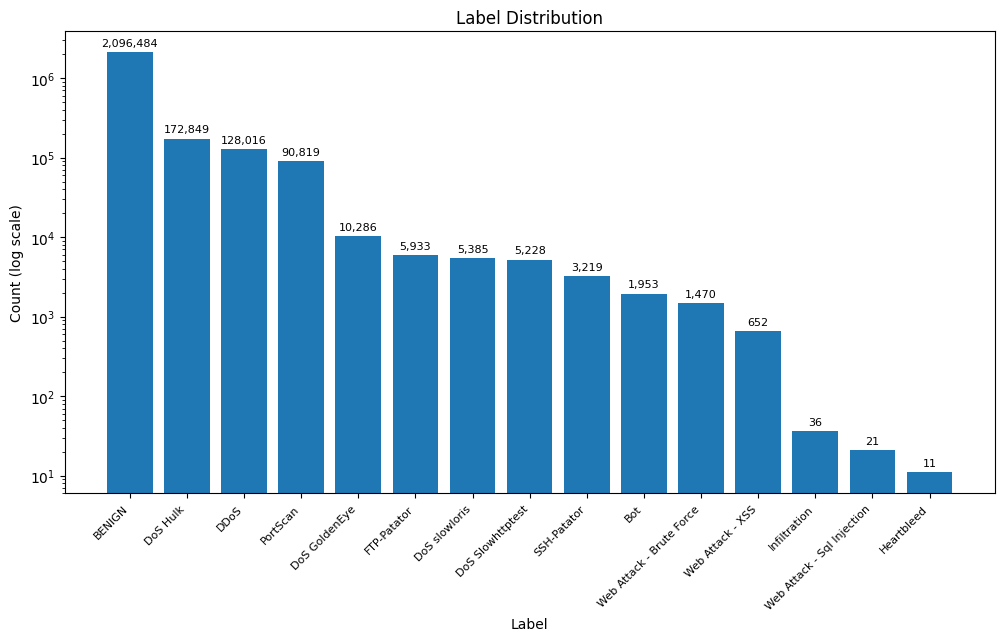

In [35]:
# plot label distribution
label_counts = df['Label'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(label_counts.index, label_counts.values)
ax.set_yscale('log') # log scale since the benign class is so large
ax.set_xlabel('Label')
ax.set_ylabel('Count (log scale)')
ax.set_title('Label Distribution')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.bar_label(bars, labels=[f'{c:,}' for c in label_counts.values], fontsize=8, padding=3)
plt.show()

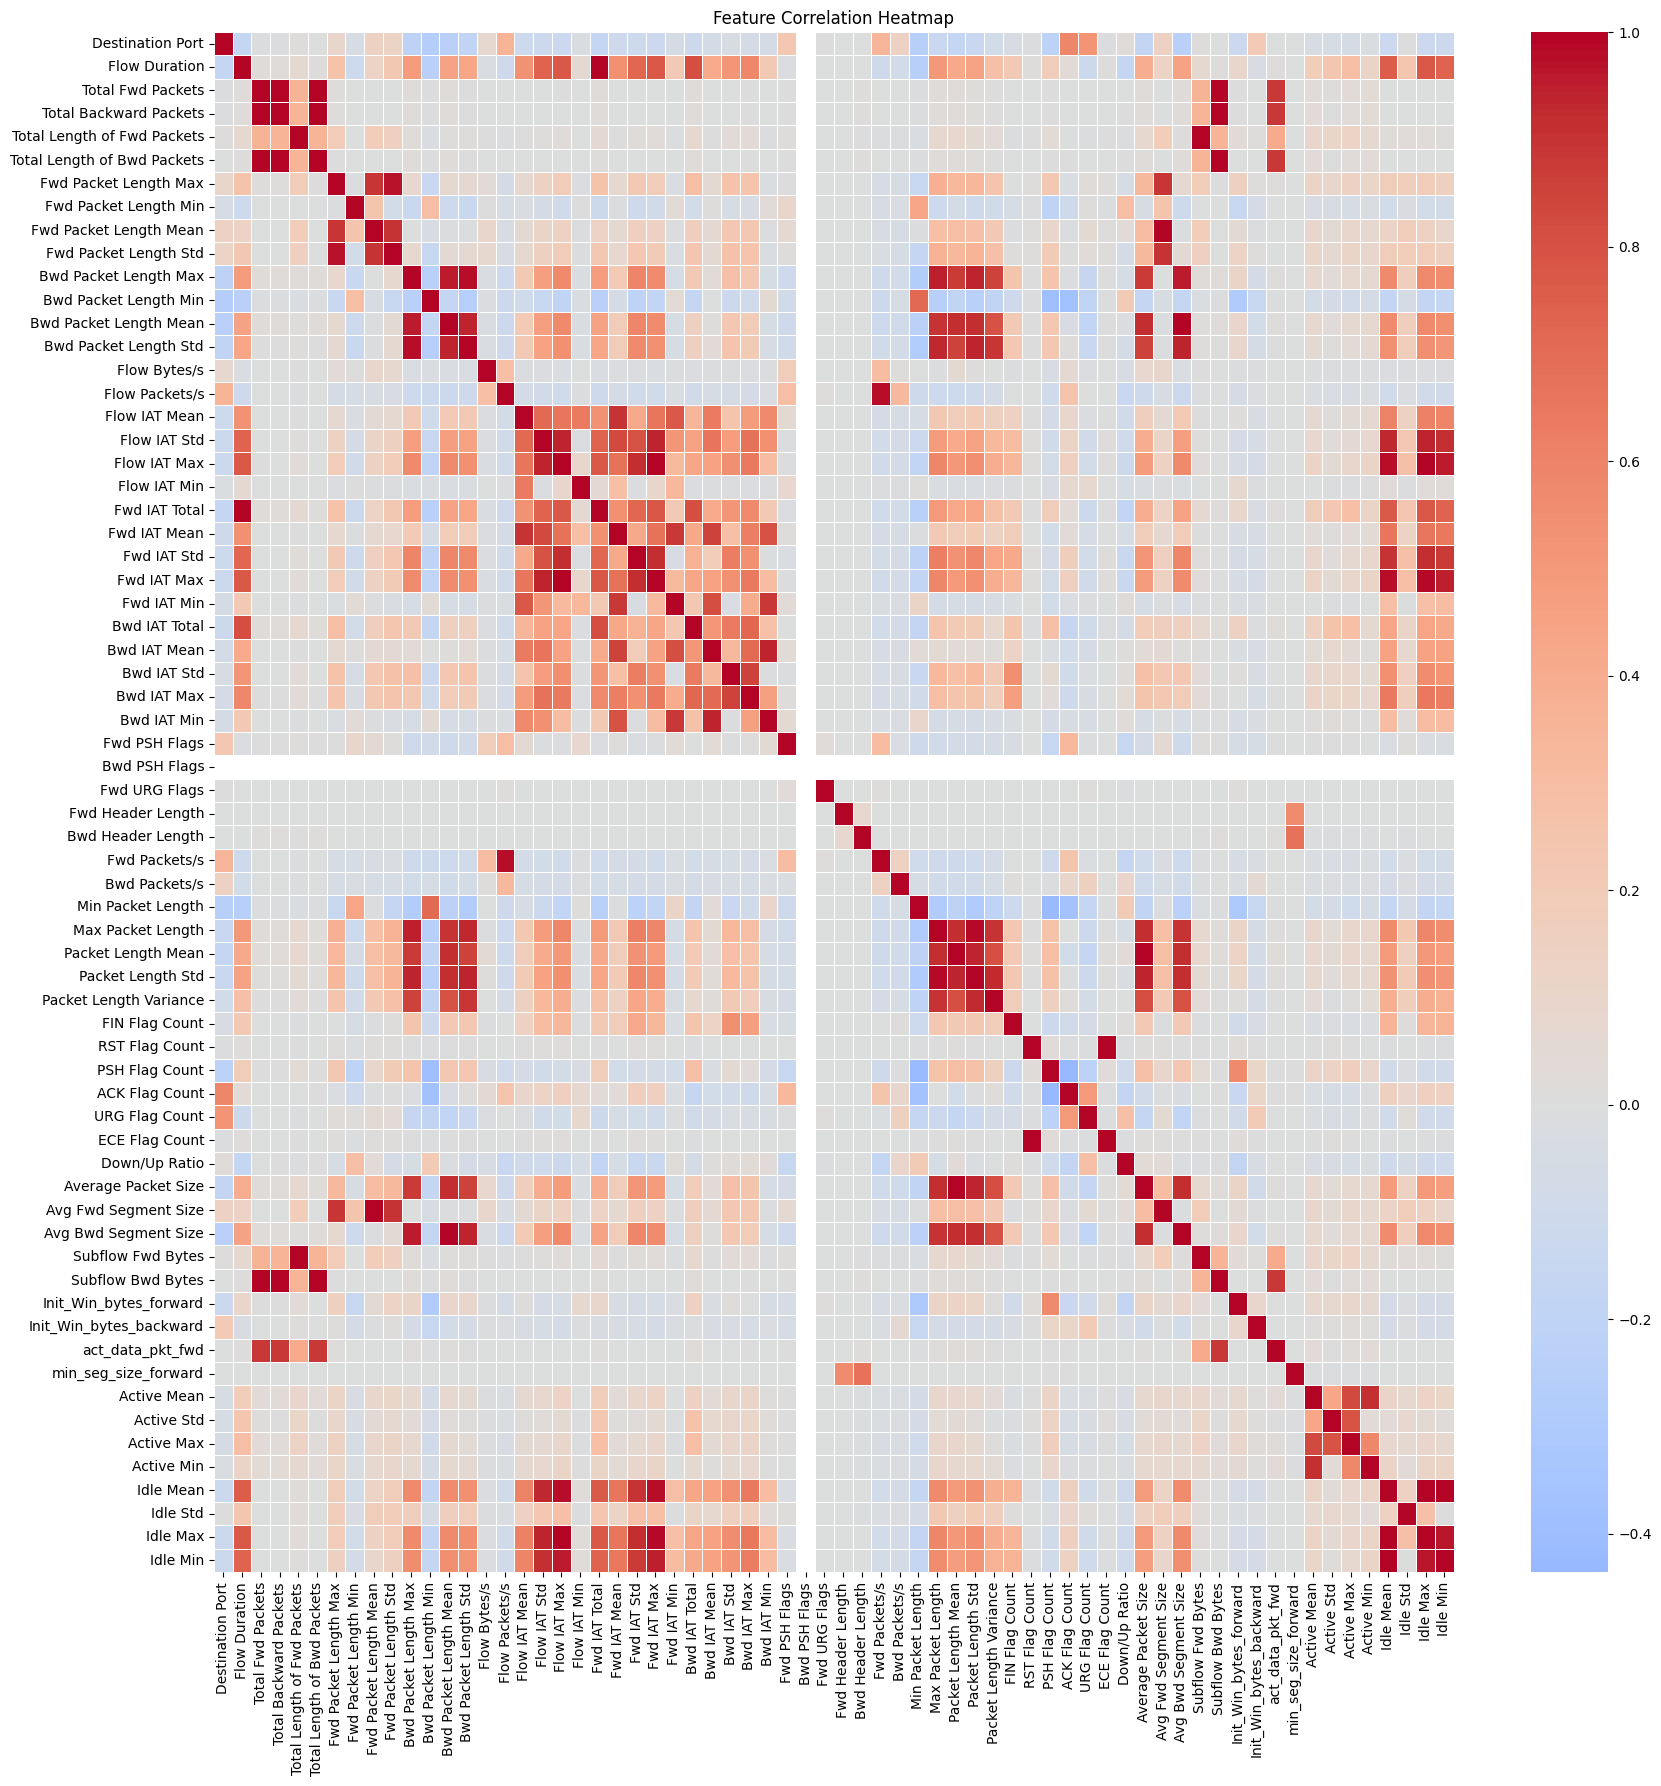

In [36]:
# Calculate correlation matrix
corr_matrix = df.select_dtypes(include='number').corr()

# Plot correlation heatmap
plt.figure(figsize=(20, 20))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, linewidth = 0.5)
plt.title('Feature Correlation Heatmap')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

In [37]:
# extract highly correlated features
threshold = 0.97
high_corr = np.where(np.abs(corr_matrix) > threshold)
high_corr = [(corr_matrix.index[x], corr_matrix.columns[y], corr_matrix.iloc[x, y]) for x, y in zip(*high_corr) if x != y and x < y]

# pretty print
# for item in high_corr:
#    print(f'{item[0]} highly correlated with {item[1]}: {item[2].round(4)}')

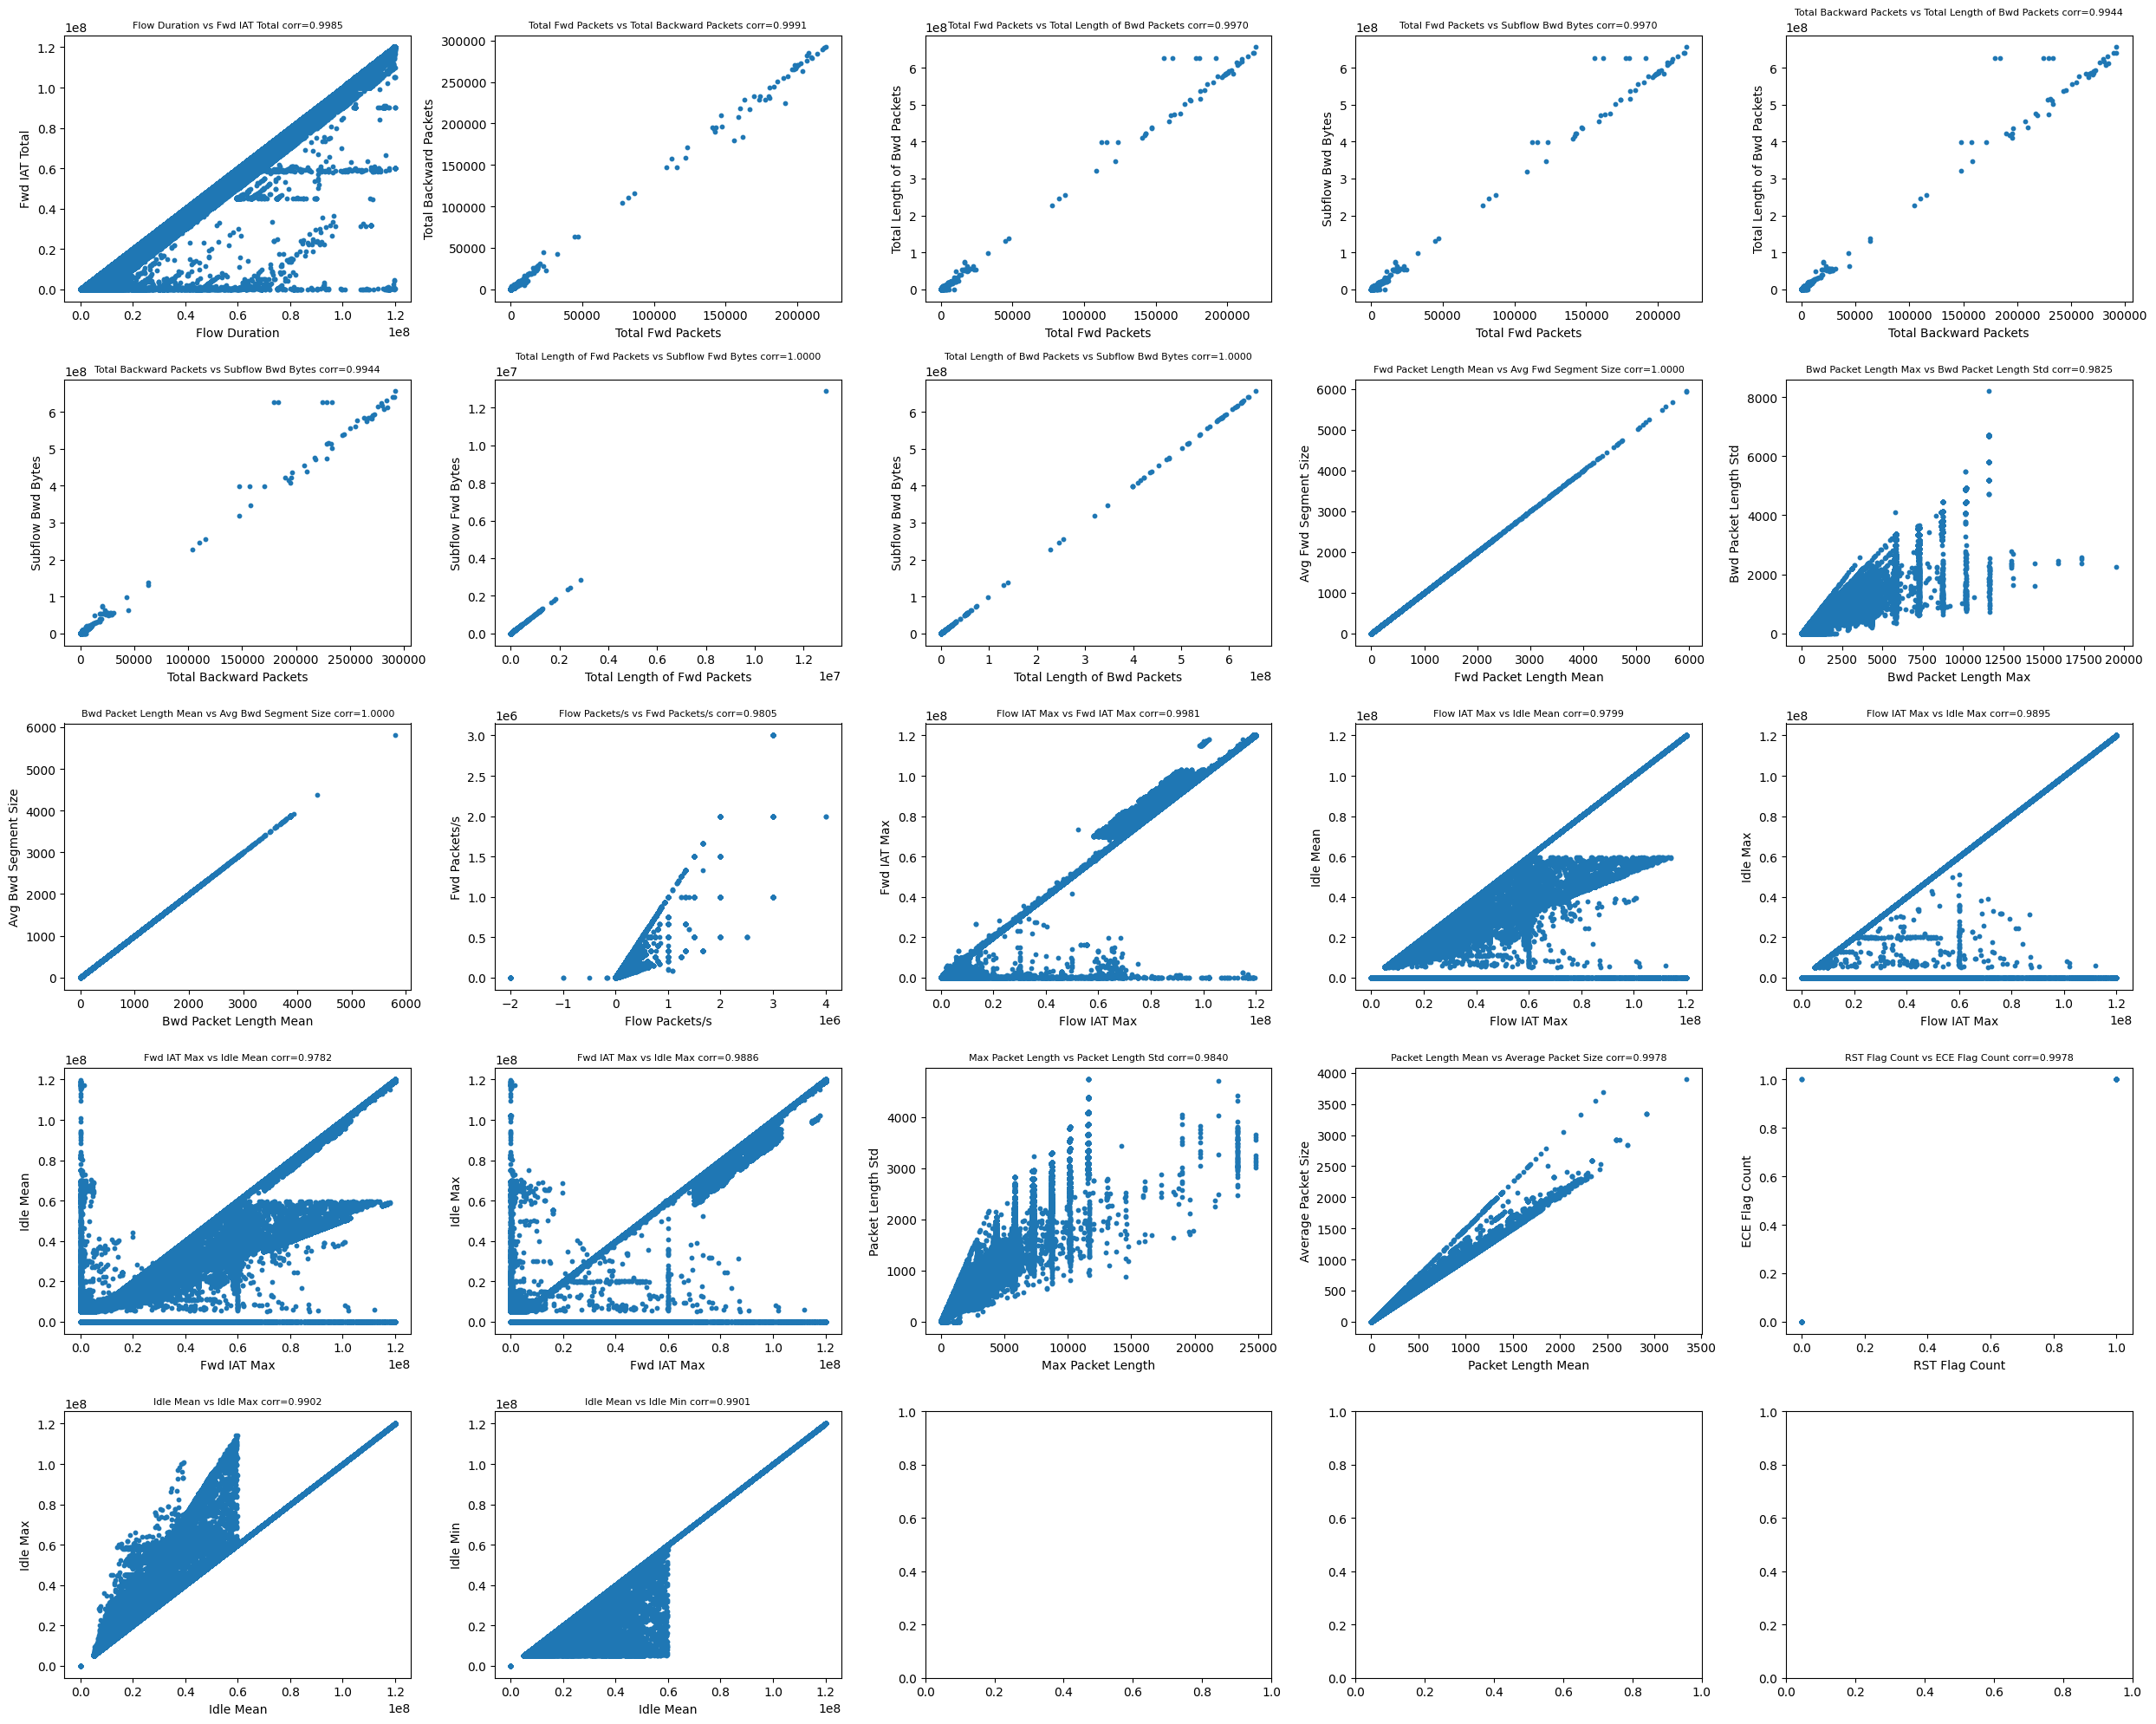

In [38]:
# plot each pair of highly correlated features
import math

cols = 5
rows = math.ceil(len(high_corr) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))

for ax, (f1, f2, corr) in zip(axes.flatten(), high_corr):
    ax.scatter(df[f1], df[f2], s=10)
    ax.set_xlabel(f1)
    ax.set_ylabel(f2)
    ax.set_title(f"{f1} vs {f2} corr={corr:.4f}", fontsize=8)

plt.tight_layout()
plt.show()

In [39]:
# from the plots, visually identify and drop features with near perfect correlation
columns_to_drop = ['Avg Bwd Segment Size', 'Avg Fwd Segment Size', 'Subflow Bwd Bytes', 'Total Backward Packets', 'Total Length of Bwd Packets']
df = df.drop(columns=columns_to_drop)
print(f"Shape: {df.shape}")

Shape: (2522362, 62)


# Training

In [43]:
# create feature and target datasets
y = df['Label']
X = df.drop(columns=['Label'])

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Under sample the majority BENIGN class
rus = RandomUnderSampler(sampling_strategy={'BENIGN': 138007}, random_state=42)
X_temp, y_temp = rus.fit_resample(X_train, y_train)

# Then over sample 
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_temp, y_temp)

print("Training Set Class Distribution:")
pd.Series(y_resampled).value_counts()

Training Set Class Distribution:


Label
BENIGN                        138007
Bot                           138007
DDoS                          138007
DoS GoldenEye                 138007
DoS Hulk                      138007
DoS Slowhttptest              138007
DoS slowloris                 138007
FTP-Patator                   138007
Heartbleed                    138007
Infiltration                  138007
PortScan                      138007
SSH-Patator                   138007
Web Attack - Brute Force      138007
Web Attack - Sql Injection    138007
Web Attack - XSS              138007
Name: count, dtype: int64

In [58]:
clf = RandomForestClassifier(n_estimators=10, max_depth=None, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    419161
                       Bot       0.86      0.67      0.76       395
                      DDoS       1.00      1.00      1.00     25587
             DoS GoldenEye       1.00      0.99      1.00      2074
                  DoS Hulk       1.00      1.00      1.00     34842
          DoS Slowhttptest       0.99      0.99      0.99      1028
             DoS slowloris       0.99      0.99      0.99      1050
               FTP-Patator       1.00      1.00      1.00      1185
                Heartbleed       1.00      1.00      1.00         1
              Infiltration       1.00      0.45      0.62        11
                  PortScan       0.99      0.99      0.99     18088
               SSH-Patator       1.00      0.99      1.00       628
  Web Attack - Brute Force       0.74      0.80      0.77       309
Web Attack - Sql Injection       0.50      0.33

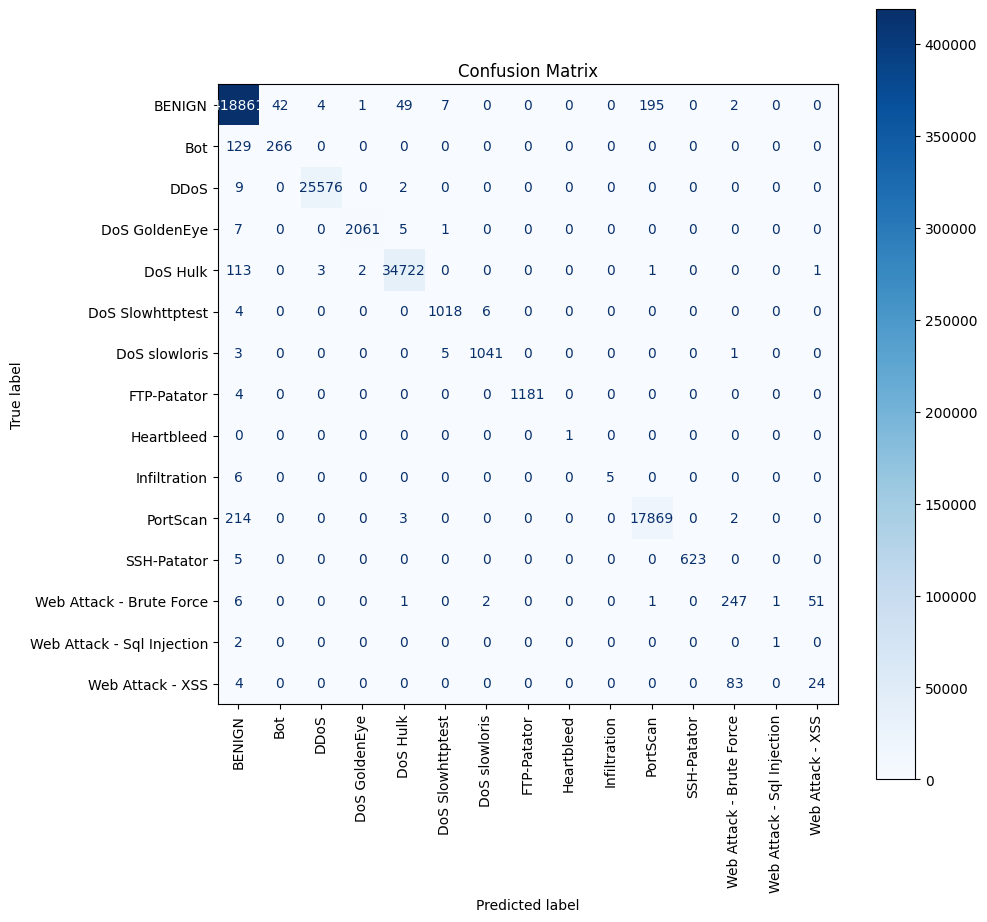

In [67]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(cmap='Blues', ax=ax, xticks_rotation=90)
plt.title('Confusion Matrix')
plt.show()